In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
class Datalogger_Processing:
    def __init__(self, filepath):
      '''
      Class for processing datalogger files

      Arg:
        filepath: string of filepath to datalogger CSV
      '''
      self.fp = filepath

      self.fp_string = self.fp.split('/')[-1]

      self.df = pd.read_csv(self.fp)

    def process(self, plotting_title=None):
      '''
      Full pipeline: plots raw data vs Timer[S], detects timer resets, creates continuous Absolute Timer (S) column,
      and plots everything again vs Absolute Timer (S). Returns self.df so it can be chained into one line.

      Usage: datalogger_df = Datalogger_Processing(fp).process()
      '''
      self.subplots()                                                  # initial plot with raw Timer[S]
      self.separate_timer_resets(plotting_title=plotting_title)        # detects resets, builds Absolute Timer (S), re-plots vs it
      return self.df                                                   # return the fully-processed dataframe so caller can grab it directly

    def subplots(self, xaxis='Timer[S]', title=None):
      '''
      Method for subplots of datalogger data

      Args:
        Columns
      '''
      if title is None:
          title = self.fp_string

      fig1, axes = plt.subplots(1, 3, figsize=(20, 5))

      axes[0].plot(self.df[xaxis], self.df['Events CW1&2'], marker='o', markersize=0.7, color='blue', label="CW 1 & 2")
      axes[0].plot(self.df[xaxis], self.df['Events CW1&2&3'], marker='o', markersize=0.7, color='magenta', label="CW 1 & 2 & 3")
      axes[0].set_xlabel(xaxis)
      axes[0].set_ylabel('Events')
      axes[0].legend()
      axes[0].set_title('CosmicWatch Events over Time')

      axes[1].plot(self.df[xaxis], self.df['Pressure[Pa]'], marker='o', markersize=0.7, color='green', label="Pressure")
      axes[1].set_xlabel(xaxis)
      axes[1].set_ylabel('Pressure[Pa]')
      axes[1].legend()
      axes[1].set_title('Pressure over Time')

      axes[2].plot(self.df[xaxis], self.df['Temperature[C]'], marker='o', markersize=0.7, color='red', label="Temperature")
      axes[2].set_xlabel(xaxis)
      axes[2].set_ylabel('Temperature[C]')
      axes[2].legend()
      axes[2].set_title('Temperature over Time')

      plt.suptitle(title)
      plt.show()

    def separate_timer_resets(self, plotting_title=None):
      '''
      Detect any timer resets in the datalogger data, and creates separate DataFrames for each run. Then creates an Absolute Timer column to add to the dataframe, and plots the data as a function of the absolute timer.
      '''
      if plotting_title is None:
          plotting_title = self.fp_string

      self.df_sorted = self.df.copy().sort_index().reset_index(drop=True)                      # make sure rows are in original order + give clean 0-based index

      time_col = 'Timer[S]'                                                    # name of the column that holds the timer values

      reset_mask = self.df_sorted[time_col].diff() < -10                                # .diff() computes row-to-row differences; this creates a boolean mask that's True wherever the time decreased by more than 3 seconds (negative value indicates a reset/jump backward)

      new_segment_starts = [0] + (reset_mask[reset_mask].index).tolist()   # list of row numbers where each new segment begins: 0 + (index of each True + 1 to point to first row of next segment)
      print(f"Detected {len(new_segment_starts)-1} separate timer reset(s) at rows {new_segment_starts}")

      self.timerreset_segments = []                                                            # empty list that will store one DataFrame per continuous run

      for i in range(len(new_segment_starts)):                                 # loop over each detected starting point
        start = new_segment_starts[i]                                        # determine starting row index of current segment; store in "start"
        end = new_segment_starts[i+1] if i+1 < len(new_segment_starts) else None   # ending row = start of next segment, or None (means go to end of DataFrame)
        seg = self.df_sorted.iloc[start:end].copy()                                  # slice out this segment and make independent copy; iloc
        seg['Timer_rel'] = seg[time_col] - seg[time_col].iloc[0]             # add relative time column that starts at ~0 for this run
        self.timerreset_segments.append(seg)                                                 # store this segment in the list

      for i, seg in enumerate(self.timerreset_segments, 1):
        t_min = seg[time_col].min()
        t_max = seg[time_col].max()
        nrows = len(seg)
        print(f"  Run {i:2d}: {nrows:5d} rows, timer {t_min:6.0f} → {t_max:6.0f} s")

      self.create_absolute_timer()

      for i, start_idx in enumerate(new_segment_starts):
        print(f"\n--- Around start of Timer Reset {i+1} (row {start_idx}) ---")

        start = max(0, start_idx - 5)
        end   = start_idx + 6

        slice_df = self.df.iloc[start:end] # Changed from self.df_sorted to self.df

        print(slice_df[[time_col, 'Events CW1&2', 'Events CW1&2&3', 'Absolute Timer (S)']].to_string(index=True))

      self.subplots(xaxis='Absolute Timer (S)', title=plotting_title)


    def create_absolute_timer(self):
      '''
      Creates continuous Absolute Timer by chaining last value from before timer reset
      '''
      absolute_timers = []
      previous_end = 0.0

      for i, seg in enumerate(self.timerreset_segments):
        current_timers = seg['Timer[S]'].values

        if len(current_timers) == 0:
            continue

        absolute_this_segment = current_timers + previous_end

        absolute_timers.extend(absolute_this_segment)

        previous_end = absolute_this_segment[-1]

      self.df['Absolute Timer (S)'] = absolute_timers

## 0 Degrees Datalogger

In [ ]:
datalogger_csv_fp = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_DATALOGGER.csv' # @param {type:"string"}
top_scint_fp = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_TOP.txt' # @param {type:"string"}
mid_scint_fp = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_MID.txt' # @param {type:"string"}
bot_scint_fp = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_BOT.txt' # @param {type:"string"}

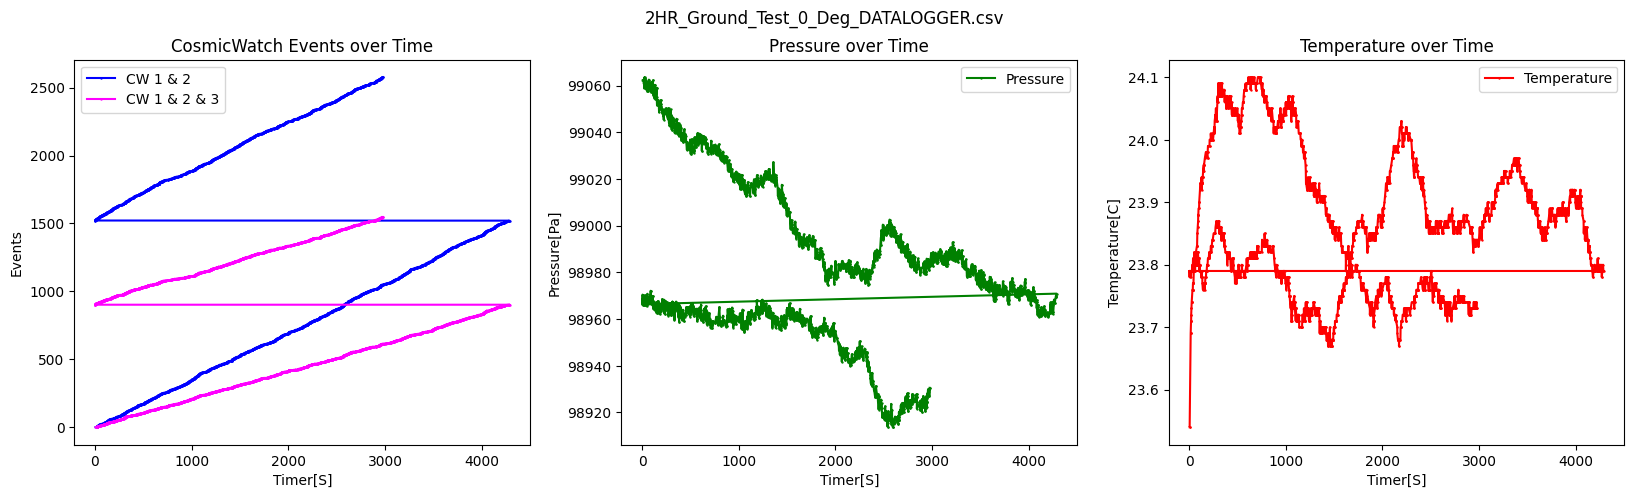

Detected 1 separate timer reset(s) at rows [0, 2423]
  Run  1:  2423 rows, timer      6 →   4289 s
  Run  2:  1702 rows, timer      2 →   2975 s

--- Around start of Timer Reset 1 (row 0) ---
    Timer[S]  Events CW1&2  Events CW1&2&3  Absolute Timer (S)
0   5.849609             1               0            5.849609
1   5.855468             1               1            5.855468
2  16.342773             2               1           16.342773
3  16.415039             3               1           16.415039
4  16.420898             3               2           16.420898
5  19.281250             4               2           19.281250

--- Around start of Timer Reset 2 (row 2423) ---
         Timer[S]  Events CW1&2  Events CW1&2&3  Absolute Timer (S)
2418  4269.168945          1518             901         4269.168945
2419  4281.617187          1519             901         4281.617187
2420  4286.391601          1520             901         4286.391601
2421  4286.411132          1520             9

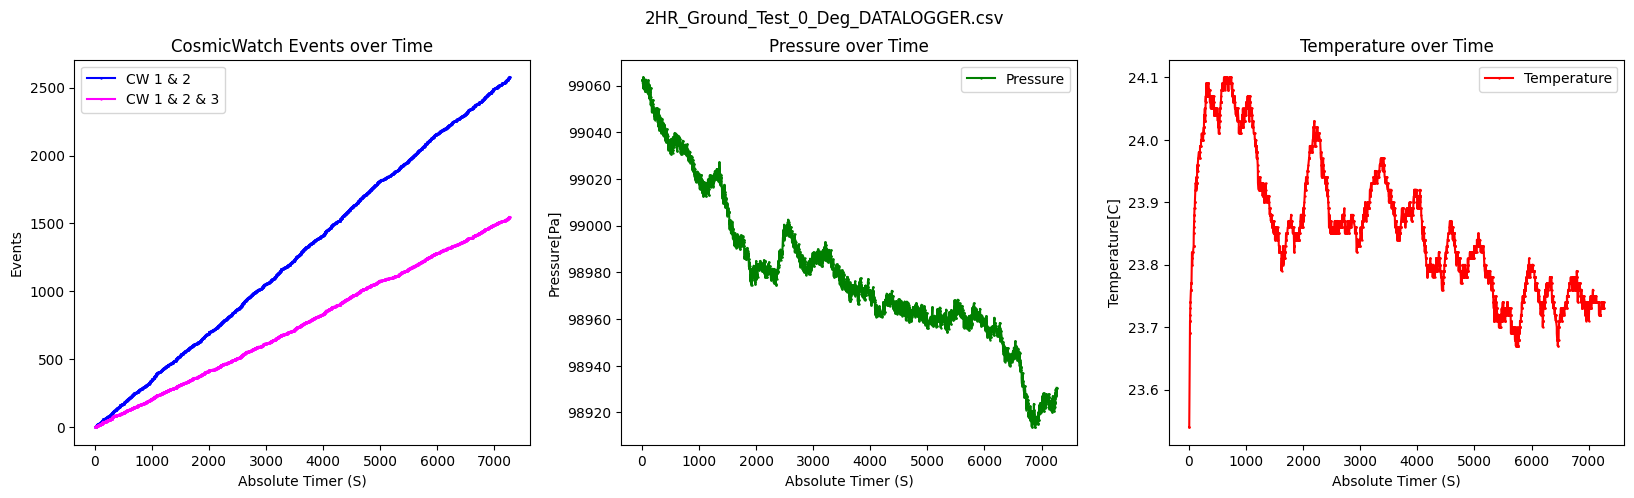

In [ ]:
datalogger_df = Datalogger_Processing(datalogger_csv_fp).process()

In [ ]:
datalogger_df

,Events CW1&2,Events CW1&2&3,Temperature[C],Pressure[Pa],Date[MM/DD/YYYY],RTC[H:M:S EST],Timer[S],Latitude,Longitude,Altitude[m],...,Accel y,Accel z,Gyro x,Gyro y,Gyro z,Mag x,Mag y,Mag z,Battery[],Absolute Timer (S)
0,1,0,23.54,99062.22,1/1/1970,0:0:10.843,5.849609,0.0,0.0,0.0,...,9.02334,-1.12223,1.97187,-0.41050,-0.04520,-68.40105,-25.02192,-85.39900,95,5.849609
1,1,1,23.54,99062.22,1/1/1970,0:0:10.843,5.855468,0.0,0.0,0.0,...,9.02334,-1.12223,1.97187,-0.41050,-0.04520,-68.40105,-25.02192,-85.39900,95,5.855468
2,2,1,23.69,99062.56,1/15/2026,0:27:08.348,16.342773,0.0,0.0,0.0,...,9.78784,0.48814,0.02443,-0.04154,-0.00489,-81.84741,-46.21456,-100.38000,94,16.342773
3,3,1,23.69,99062.15,1/15/2026,0:27:08.421,16.415039,0.0,0.0,0.0,...,9.79143,0.48933,0.02321,-0.04032,-0.00489,-81.08740,-45.89301,-98.90382,94,16.415039
4,3,2,23.69,99062.15,1/15/2026,0:27:08.421,16.420898,0.0,0.0,0.0,...,9.79143,0.48933,0.02321,-0.04032,-0.00489,-81.08740,-45.89301,-98.90382,94,16.420898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4120,2575,1546,23.73,98929.57,1/15/2026,2:28:10.386,2968.011219,0.0,0.0,0.0,...,9.79502,0.46540,0.02321,-0.03910,-0.00489,-79.74277,-48.49459,-107.48318,96,7256.871570
4121,2576,1546,23.74,98927.02,1/15/2026,2:28:14.683,2972.255360,0.0,0.0,0.0,...,9.78306,0.47019,0.02321,-0.04032,-0.00489,-78.99737,-48.05612,-107.99474,96,7261.115711
4122,2576,1547,23.74,98927.02,1/15/2026,2:28:14.683,2972.271961,0.0,0.0,0.0,...,9.78306,0.47019,0.02321,-0.04032,-0.00489,-78.99737,-48.05612,-107.99474,96,7261.132312
4123,2577,1547,23.73,98930.53,1/15/2026,2:28:17.522,2975.080555,0.0,0.0,0.0,...,9.79143,0.46660,0.02321,-0.04032,-0.00489,-79.20198,-48.91845,-108.30167,96,7263.940906


In [ ]:
print([repr(c) for c in datalogger_df.columns])

["'Events CW1&2'", "'Events CW1&2&3'", "'Temperature[C]'", "'Pressure[Pa]'", "'Date[MM/DD/YYYY]'", "'RTC[H:M:S EST]'", "'Timer[S]'", "'Latitude'", "'Longitude'", "'Altitude[m]'", "'Sats'", "'Accel x'", "'Accel y'", "'Accel z'", "'Gyro x'", "'Gyro y'", "'Gyro z'", "'Mag x'", "'Mag y'", "'Mag z'", "'Battery[]'", "'Absolute Timer (S)'"]


The datalogger file contains coincidence events across CosmicWatches 1&2, and 1, 2 & 3 along with the time stamps for all coincidence events. However, the scintillator files for each individual CosmicWatch contain data with a timestamp of any time that individual CosmicWatch scintillated. We are interested in the signal in mV on each individual scintillator at the point in time where there was three scintillator coincidence. In other words, we want to see the SiPM signal, in mV, for each scintillator (located in the files for each scintillator) ONLY at the time stamps where there was three-scintillator coincidence, indicating a pure muon sample.

In [3]:
class Scintillator_Processing:
    def __init__(self, filepaths):
      '''
      Class for processing scintillator files

      Arg:
        filepaths: list of filepath strings for each scintillator TXT
      '''
      self.fps = filepaths

      columns = ['Event','Time[s]','Coincident[bool]','ADC[0-4095]','SiPM[mV]','Deadtime[s]','Temp[C]','Pressure[Pa]']

      for i, fp in enumerate(filepaths, start=1):
            df = pd.read_csv(fp, sep='\t', comment='#', header=None, skiprows=3, names=columns, engine='python')
            setattr(self, f'scint_{i}', df)

    def plot_all_scintillators(self, datalogger_df_raw):
      self.align_with_datalogger(datalogger_df_raw)  # once, not per scintillator

      for i in range(1, len(self.fps) + 1):
          self.plot_CoincidenceRates_vs_SiPMVoltage(i)  # no scint_df or datalogger arg needed

      colors = ['blue', 'orange', 'green', 'red', 'purple']
      fig, ax = plt.subplots(figsize=(8, 4))
      for i in range(1, len(self.fps) + 1):
          cw123_data = self.aligned_df[f'SiPM_mV_CW123_scint{i}'].dropna()
          print(f"\nScintillator {i} \u2014 SiPM_mV_CW123 stats:")
          print(f"  Non-null count: {len(cw123_data)}")
          print(f"  Min: {cw123_data.min():.2f} mV, Max: {cw123_data.max():.2f} mV, Mean: {cw123_data.mean():.2f} mV")
          ax.hist(cw123_data, bins=100,
                  color=colors[(i-1) % len(colors)], edgecolor='black',
                  alpha=0.5, label=f'Scintillator {i}')
      ax.set_xlabel('SiPM[mV]', fontsize=12)
      ax.set_ylabel('Count', fontsize=12)
      ax.set_title('SiPM Voltage Distribution \u2014 All Scintillators', fontsize=12)
      ax.set_yscale('log')
      ax.legend(fontsize=11)
      plt.tight_layout()
      plt.show()

    def plot_CoincidenceRates_vs_SiPMVoltage(self, i):
        binned = getattr(self, f'binned_and_aligned_df_{i}')

        fig, (ax, ax3) = plt.subplots(1, 2, figsize=(16, 6))

        ax.errorbar(binned['mean_mV'], binned['mean_rate_12'],
              yerr=binned['err_12'], fmt='o-', color='darkorange',
              lw=1.5, markersize=4, label='CW 1+2 Coincident Rate', capsize=3)
        ax.errorbar(binned['mean_mV'], binned['mean_rate_123'],
                    yerr=binned['err_123'], fmt='o-', color='steelblue',
                    lw=1.5, markersize=4, label='CW 1+2+3 Coincident Rate', capsize=3)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(f'SiPM Peak Voltage [mV] (Scintillator {i})', fontsize=13)
        ax.set_ylabel(r'Mean Count Rate [s$^{-1}$]', fontsize=13)
        ax.set_title(f'CW Coincident Rate vs. Scintillator {i} SiPM Voltage\n(0° Ground Test \u2014 Timestamp Aligned, Log-Log)', fontsize=13)
        ax.legend(fontsize=11)
        ax.grid(True, which='both', linestyle='--', alpha=0.4)

        ax3.hist(self.aligned_df[f'SiPM_mV_CW123_scint{i}'].dropna(), bins=100, color='blue', edgecolor='black')
        ax3.set_xlabel('SiPM[mV]', fontsize=12)
        ax3.set_ylabel('Count', fontsize=12)
        ax3.set_title(f'SiPM Voltage Distribution for Scintillator {i}\n(Triple Coincidence Events Only)', fontsize=12)
        ax3.set_yscale('log')

        plt.tight_layout()
        plt.show()

      # fig2, ax2 = plt.subplots(figsize=(8, 4))
      # ax2.hist(aligned['dt_match[s]'].dropna(), bins=100, color='gray', edgecolor='black')
      # ax2.set_xlabel('Timestamp Match Offset [s]', fontsize=12)
      # ax2.set_ylabel('Count', fontsize=12)
      # ax2.set_title('Diagnostic: Timestamp Match Offsets (should peak near 0 because most timestamps between datalogger and scintillator files \n should be very close; should be very few large time offsets)', fontsize=12)
      # ax2.set_yscale('log')
      # plt.tight_layout()
      # plt.show()

    def align_with_datalogger(self, datalogger_df_raw, NUM_BINS=50):
      dl_df = datalogger_df_raw.sort_values('Absolute Timer (S)').reset_index(drop=True)
      aligned = dl_df.copy()

      for i in range(1, len(self.fps) + 1):
          scint_df = getattr(self, f'scint_{i}')[['Time[s]','SiPM[mV]','ADC[0-4095]','Coincident[bool]']].copy()
          scint_df = scint_df.rename(columns={
              'Time[s]':          f'Time_scint{i}[s]',
              'SiPM[mV]':         f'SiPM_scint{i}[mV]',
              'ADC[0-4095]':      f'ADC_scint{i}[0-4095]',
              'Coincident[bool]': f'Coincident_scint{i}[bool]'
          }).sort_values(f'Time_scint{i}[s]').reset_index(drop=True)

          aligned = pd.merge_asof(
              aligned, scint_df,
              left_on='Absolute Timer (S)',
              right_on=f'Time_scint{i}[s]',
              direction='nearest',
              tolerance=5.0
          )

      print(f"Aligned/combined dataframe headers {aligned.columns}")

      aligned['dt_match[s]'] = (aligned['Absolute Timer (S)'] - aligned['Time_scint1[s]']).abs()
      print(f"\nMatch offset stats (seconds):")
      print(aligned['dt_match[s]'].describe().round(4))

      # FIXED: 60s bin-based rate
      BIN_SIZE = 60.0
      t = aligned['Absolute Timer (S)'].values
      bin_edges_time = np.arange(t.min(), t.max() + BIN_SIZE, BIN_SIZE)

      delta_12  = aligned['Events CW1&2'].diff().clip(lower=0).fillna(0).values
      delta_123 = aligned['Events CW1&2&3'].diff().clip(lower=0).fillna(0).values
      delta_t   = aligned['Absolute Timer (S)'].diff().clip(lower=0).fillna(0).values

      counts_12,   _ = np.histogram(t, bins=bin_edges_time, weights=delta_12)
      counts_123,  _ = np.histogram(t, bins=bin_edges_time, weights=delta_123)
      bin_livetime,_ = np.histogram(t, bins=bin_edges_time, weights=delta_t)

      valid = bin_livetime > 0
      rate_12_binned  = np.where(valid, counts_12  / bin_livetime, np.nan)
      rate_123_binned = np.where(valid, counts_123 / bin_livetime, np.nan)

      print(f"\nMean CW1+2 rate:   {np.nanmean(rate_12_binned):.3f} s⁻¹")
      print(f"Mean CW1+2+3 rate: {np.nanmean(rate_123_binned):.3f} s⁻¹")

      bin_idx = np.clip(np.digitize(t, bin_edges_time) - 1, 0, len(rate_12_binned) - 1)
      aligned['rate_CW12']  = rate_12_binned[bin_idx]
      aligned['rate_CW123'] = rate_123_binned[bin_idx]

      # delta_CW123 still needed to filter triple coincidence rows below
      aligned['delta_CW123'] = aligned['Events CW1&2&3'].diff().clip(lower=0).fillna(0)
      # ──────────────────────────────────────────────────────────────────────

      for i in range(1, len(self.fps) + 1):
          aligned[f'SiPM_mV_CW123_scint{i}'] = aligned[f'SiPM_scint{i}[mV]'].where(aligned['delta_CW123'] > 0)

      aligned['SiPM_diff_scint1_minus_scint2'] = aligned['SiPM_mV_CW123_scint1'] - aligned['SiPM_mV_CW123_scint2']
      aligned['SiPM_diff_scint2_minus_scint3'] = aligned['SiPM_mV_CW123_scint2'] - aligned['SiPM_mV_CW123_scint3']

      self.aligned_df = aligned.copy()

      for i in range(1, len(self.fps) + 1):
          plot_df = aligned[aligned['delta_CW123'] > 0].dropna(
              subset=[f'SiPM_scint{i}[mV]', 'rate_CW12', 'rate_CW123']).copy()
          print(f"\nScint {i} rows for plotting: {len(plot_df)}")

          sipm_min  = max(aligned[f'SiPM_mV_CW123_scint{i}'].dropna().min(), 0.1)
          sipm_max  = aligned[f'SiPM_mV_CW123_scint{i}'].dropna().max()
          bin_edges = np.logspace(np.log10(sipm_min), np.log10(sipm_max), NUM_BINS + 1)

          plot_df['mV_bin'] = pd.cut(plot_df[f'SiPM_scint{i}[mV]'], bins=bin_edges, include_lowest=True)

          binned = plot_df.groupby('mV_bin', observed=True).agg(
              mean_mV = (f'SiPM_scint{i}[mV]', 'mean'),
              mean_rate_12  = ('rate_CW12',           'mean'),
              mean_rate_123 = ('rate_CW123',          'mean'),
              n_events = (f'SiPM_scint{i}[mV]', 'count'),
          ).reset_index()

          binned['err_12']  = binned['mean_rate_12']  / np.sqrt(binned['n_events'].clip(lower=1))
          binned['err_123'] = binned['mean_rate_123'] / np.sqrt(binned['n_events'].clip(lower=1))
          binned = binned.dropna(subset=['mean_mV'])
          setattr(self, f'binned_and_aligned_df_{i}', binned.copy())

Aligned/combined dataframe headers Index(['Events CW1&2', 'Events CW1&2&3', 'Temperature[C]', 'Pressure[Pa]',
       'Date[MM/DD/YYYY]', 'RTC[H:M:S EST]', 'Timer[S]', 'Latitude',
       'Longitude', 'Altitude[m]', 'Sats', 'Accel x', 'Accel y', 'Accel z',
       'Gyro x', 'Gyro y', 'Gyro z', 'Mag x', 'Mag y', 'Mag z', 'Battery[]',
       'Absolute Timer (S)', 'Time_scint1[s]', 'SiPM_scint1[mV]',
       'ADC_scint1[0-4095]', 'Coincident_scint1[bool]', 'Time_scint2[s]',
       'SiPM_scint2[mV]', 'ADC_scint2[0-4095]', 'Coincident_scint2[bool]',
       'Time_scint3[s]', 'SiPM_scint3[mV]', 'ADC_scint3[0-4095]',
       'Coincident_scint3[bool]'],
      dtype='object')

Match offset stats (seconds):
count    4125.0000
mean        0.2618
std         0.2634
min         0.0000
25%         0.0711
50%         0.1793
75%         0.3738
max         2.0641
Name: dt_match[s], dtype: float64

Scint 1 rows for plotting: 1548

Scint 2 rows for plotting: 1548

Scint 3 rows for plotting: 1548


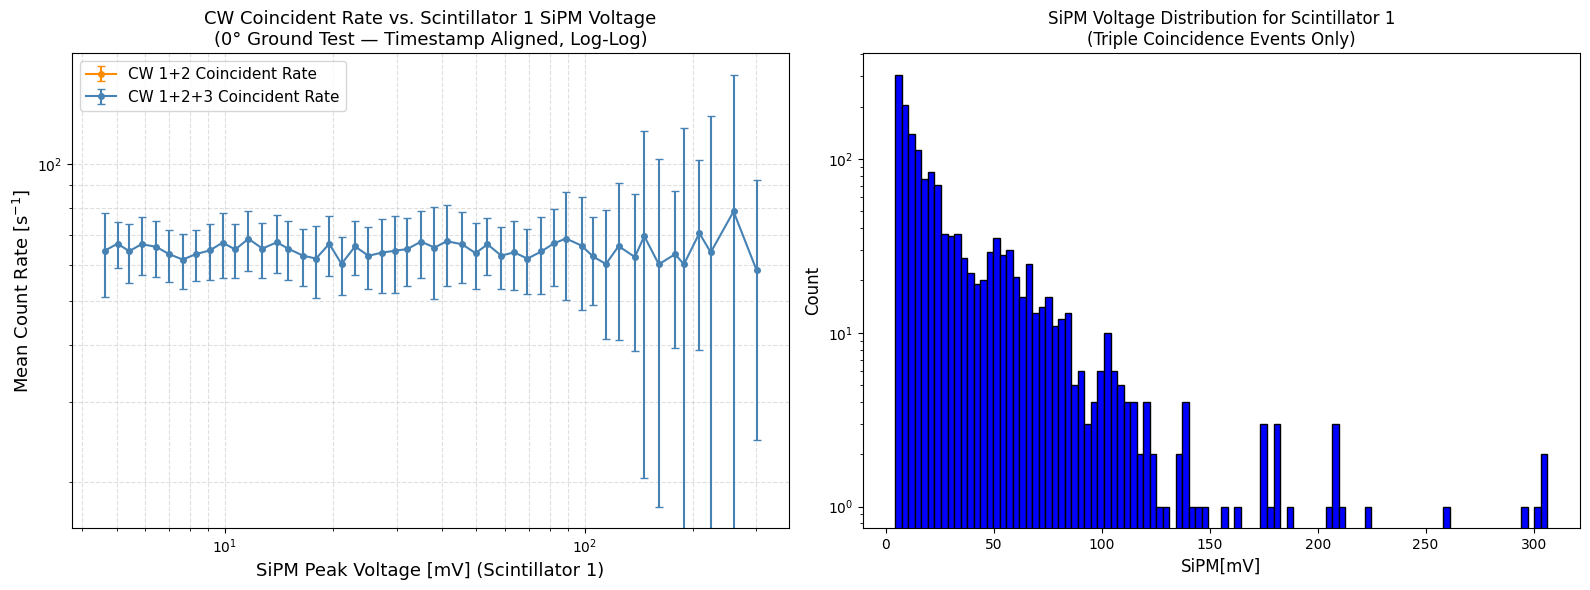

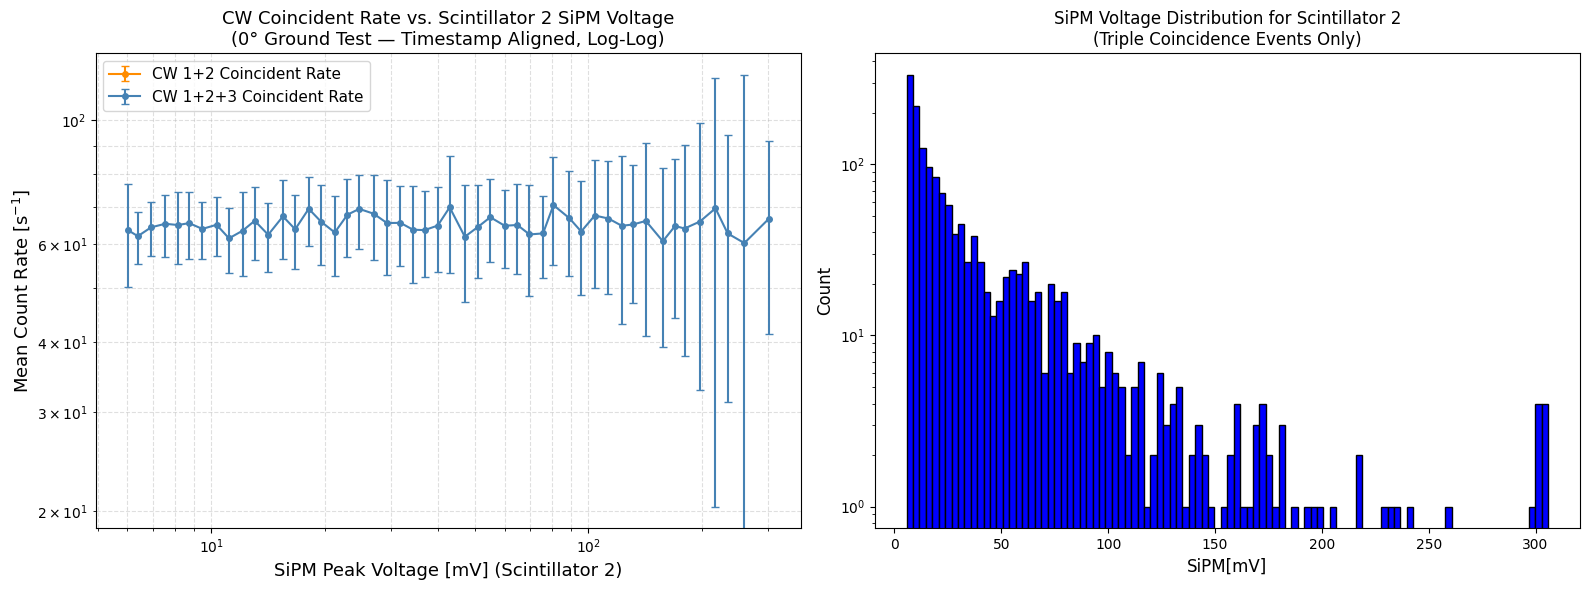

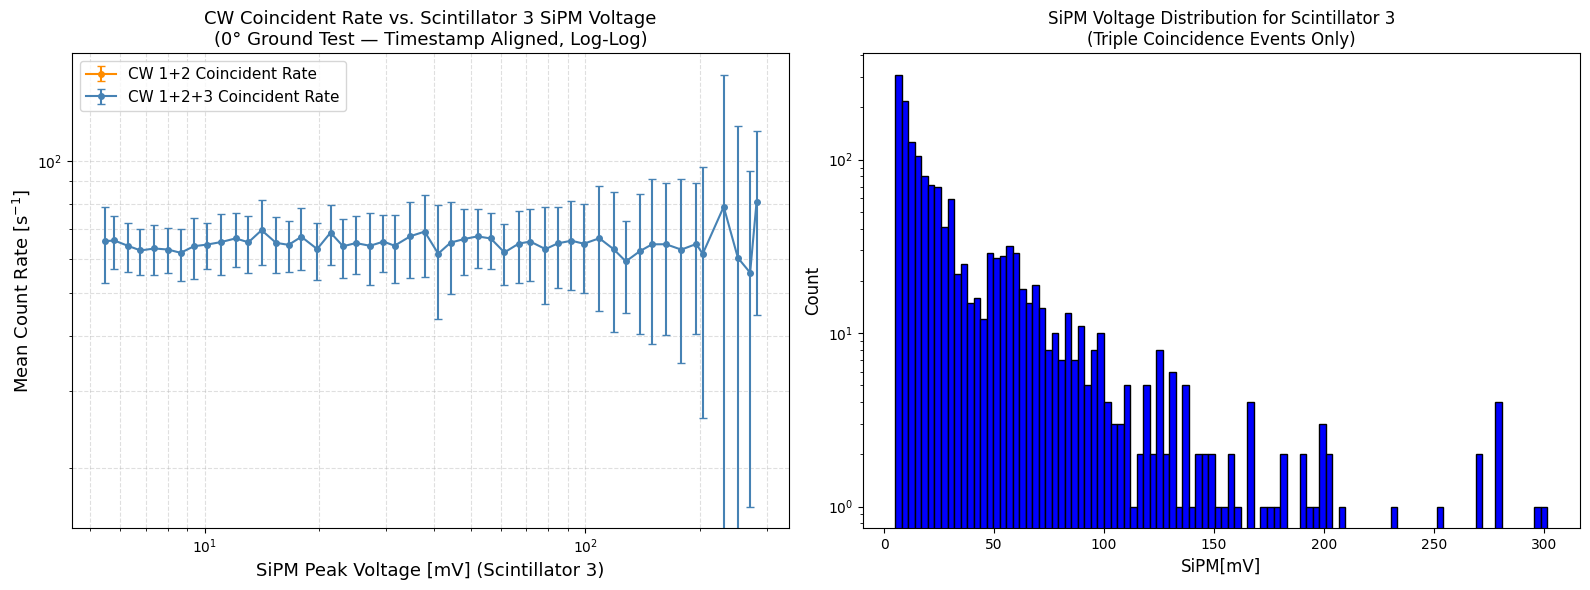


Scintillator 1 — SiPM_mV_CW123 stats:
  Non-null count: 1548
  Min: 4.40 mV, Max: 306.40 mV, Mean: 30.58 mV

Scintillator 2 — SiPM_mV_CW123 stats:
  Non-null count: 1548
  Min: 5.70 mV, Max: 305.80 mV, Mean: 34.50 mV

Scintillator 3 — SiPM_mV_CW123 stats:
  Non-null count: 1548
  Min: 5.10 mV, Max: 301.50 mV, Mean: 33.03 mV


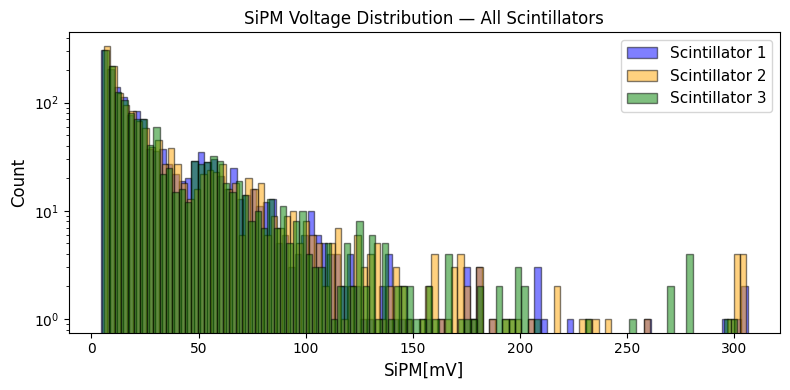

In [ ]:
three_scintillator_coincidence = Scintillator_Processing([top_scint_fp, mid_scint_fp, bot_scint_fp])
three_scintillator_coincidence.plot_all_scintillators(datalogger_df)

In [ ]:
three_scintillator_coincidence.aligned_df

,Events CW1&2,Events CW1&2&3,Temperature[C],Pressure[Pa],Date[MM/DD/YYYY],RTC[H:M:S EST],Timer[S],Latitude,Longitude,Altitude[m],...,delta_CW12,delta_CW123,delta_t,rate_CW12,rate_CW123,SiPM_mV_CW123_scint1,SiPM_mV_CW123_scint2,SiPM_mV_CW123_scint3,SiPM_diff_scint1_minus_scint2,SiPM_diff_scint2_minus_scint3
0,1,0,23.54,99062.22,1/1/1970,0:0:10.843,5.849609,0.0,0.0,0.0,...,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,23.54,99062.22,1/1/1970,0:0:10.843,5.855468,0.0,0.0,0.0,...,0.0,1.0,0.005859,0.000000,170.677590,10.8,31.8,17.6,-21.0,14.2
2,2,1,23.69,99062.56,1/15/2026,0:27:08.348,16.342773,0.0,0.0,0.0,...,1.0,0.0,10.487305,0.095353,0.000000,NaN,NaN,NaN,NaN,NaN
3,3,1,23.69,99062.15,1/15/2026,0:27:08.421,16.415039,0.0,0.0,0.0,...,1.0,0.0,0.072266,13.837766,0.000000,NaN,NaN,NaN,NaN,NaN
4,3,2,23.69,99062.15,1/15/2026,0:27:08.421,16.420898,0.0,0.0,0.0,...,0.0,1.0,0.005859,0.000000,170.677590,54.0,44.7,18.4,9.3,26.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4120,2575,1546,23.73,98929.57,1/15/2026,2:28:10.386,2968.011219,0.0,0.0,0.0,...,0.0,1.0,0.019531,0.000000,51.200655,15.3,17.1,167.4,-1.8,-150.3
4121,2576,1546,23.74,98927.02,1/15/2026,2:28:14.683,2972.255360,0.0,0.0,0.0,...,1.0,0.0,4.244141,0.235619,0.000000,NaN,NaN,NaN,NaN,NaN
4122,2576,1547,23.74,98927.02,1/15/2026,2:28:14.683,2972.271961,0.0,0.0,0.0,...,0.0,1.0,0.016601,0.000000,60.237335,14.8,10.4,23.5,4.4,-13.1
4123,2577,1547,23.73,98930.53,1/15/2026,2:28:17.522,2975.080555,0.0,0.0,0.0,...,1.0,0.0,2.808594,0.356050,0.000000,NaN,NaN,NaN,NaN,NaN
